In [ ]:
### Regression

## Problem Statement
- Predict the sales based on TV, radio and newspaper advertising budget
- Sales is the dependent variable

In [ ]:
### import required packages

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
### Load the dataset

In [60]:
df = pd.read_csv("C:\\Users\\sainya.vishwakarma\\Python\\ML4\\Advertising.csv")
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [61]:
### exploratory data analysis

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [63]:
### Get the statistical info of dataset

In [64]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [65]:
### Check if any null value

In [66]:
df.isna().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [67]:
### correlation analysis

In [68]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


In [69]:
### heatmap

<Axes: >

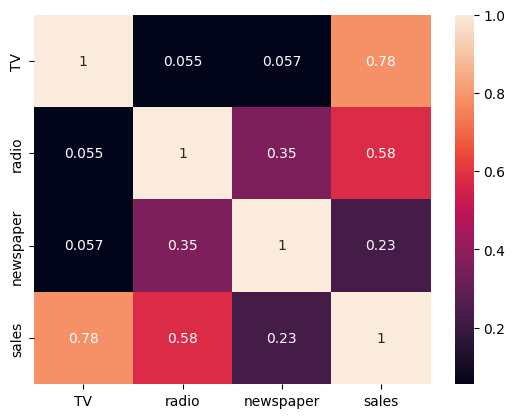

In [70]:
sns.heatmap(df.corr(),annot=True)

In [71]:
### visualize the relationships

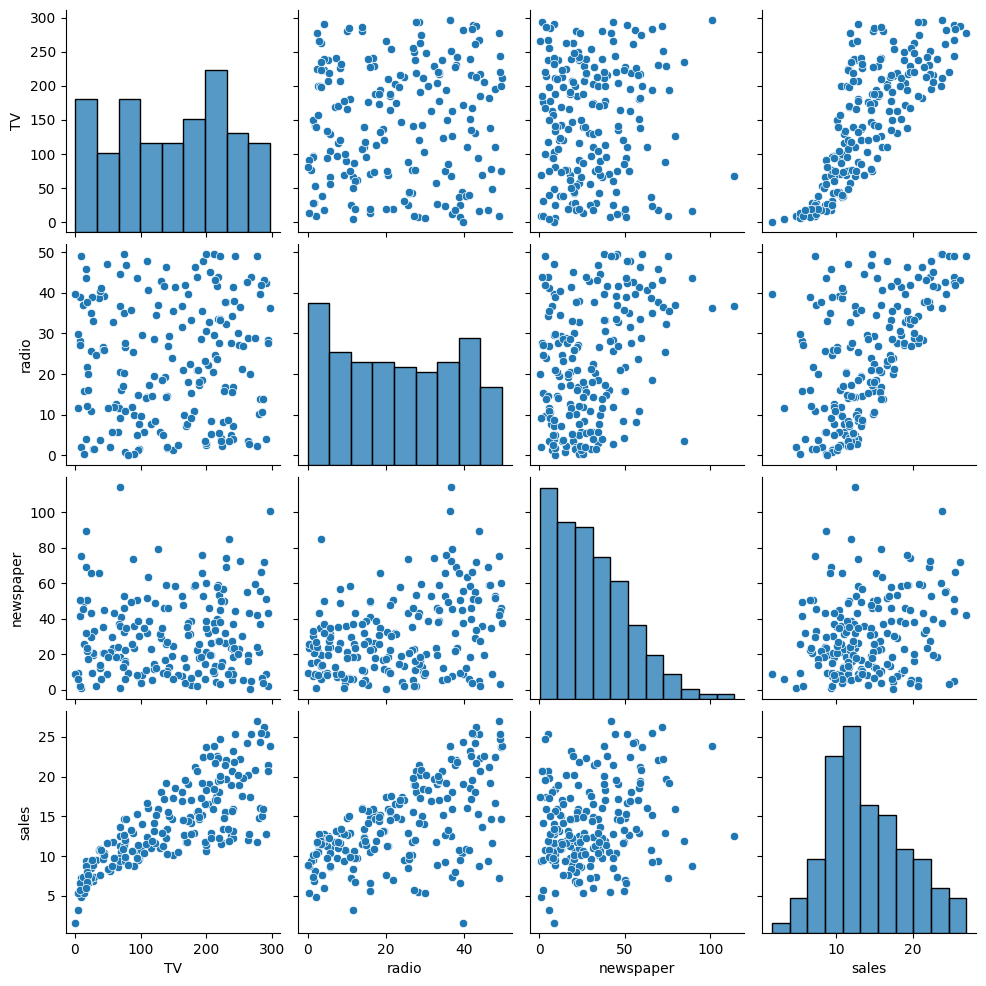

In [72]:
sns.pairplot(df)

In [73]:
### split the data into x and y

In [74]:
x = df.drop('sales',axis = 1)
y= df['sales']
x,y

(        TV  radio  newspaper
 0    230.1   37.8       69.2
 1     44.5   39.3       45.1
 2     17.2   45.9       69.3
 3    151.5   41.3       58.5
 4    180.8   10.8       58.4
 ..     ...    ...        ...
 195   38.2    3.7       13.8
 196   94.2    4.9        8.1
 197  177.0    9.3        6.4
 198  283.6   42.0       66.2
 199  232.1    8.6        8.7
 
 [200 rows x 3 columns],
 0      22.1
 1      10.4
 2       9.3
 3      18.5
 4      12.9
        ... 
 195     7.6
 196     9.7
 197    12.8
 198    25.5
 199    13.4
 Name: sales, Length: 200, dtype: float64)

In [75]:
### split the data into train and test datasets

In [76]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [77]:
### train the models

In [78]:
from sklearn.linear_model import LinearRegression

def create_linear_model():

    #create the model
    model = LinearRegression()

    # train the model
    model.fit(x_train,y_train)

    # return the model
    return model

In [79]:
from sklearn.linear_model import Lasso

def create_lasso_model():

    #create the model
    model = Lasso(alpha = 1.5)

    # train the model
    model.fit(x_train,y_train)

    # return the model
    return model

In [80]:
from sklearn.linear_model import Ridge

def create_ridge_model():

    #create the model
    model = Ridge(alpha=1.5)

    # train the model
    model.fit(x_train,y_train)

    # return the model
    return model

In [81]:
from sklearn.linear_model import ElasticNet

def create_elastic_net_model():

    #create the model
    model = ElasticNet(alpha = 1.5)

    # train the model
    model.fit(x_train,y_train)

    # return the model
    return model

In [82]:
### create all the models

linaer_regression_model = create_linear_model()
lasso_regression_model = create_lasso_model()
ridge_regression_model = create_ridge_model()
elastic_net_regression_model = create_elastic_net_model()

# create a list of models

models = [
    {"model_name":"Linear Regression","model" : linaer_regression_model},
    {"model_name":"Lasso Regression","model" :lasso_regression_model},
     {"model_name":"Ridge Regression","model" :ridge_regression_model},
     {"model_name":"Elastic Net Regression","model" :elastic_net_regression_model}
]

In [83]:
models

[{'model_name': 'Linear Regression', 'model': LinearRegression()},
 {'model_name': 'Lasso Regression', 'model': Lasso(alpha=1.5)},
 {'model_name': 'Ridge Regression', 'model': Ridge(alpha=1.5)},
 {'model_name': 'Elastic Net Regression', 'model': ElasticNet(alpha=1.5)}]

In [84]:
### model evaluation

In [85]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error,r2_score 

def evaluate_model(model,model_name):
    # predict the values from x_test
    y_pred = model.predict(x_test)

    # calculate all the metrics
    mae = mean_absolute_error(y_test,y_pred)
    mape = mean_absolute_percentage_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = root_mean_squared_error(y_test,y_pred)
    r2s = r2_score(y_test,y_pred)

    return model_name,mae,mape,mse,rmse,r2s 
    # print all the errors
    print(f"mean absolute error: {mae:.2f}")
    print(f"mean absolute percentage error: {mape:.2f}")
    print(f"mean squared error: {mse:.2f}")
    print(f"root mean squared error: {rmse:.2f}")
    print(f"r2 score: {r2s:.2f}")

In [86]:
# evaluate all the models and build the evaluation report

evaluation_metrics = []

# evaluate every model
for model_info in models:

    # get the evaluation metrics
    metrics = evaluate_model(
        model_name=model_info['model_name'],model = model_info['model'])
    # append all metrics
    evaluation_metrics.append(metrics)


In [88]:
# create a dataframe from evaluation metric
pd.DataFrame(evaluation_metrics,columns=['Model','MAE','MAPE','MSE','RMSE','R2 Score'])

,Model,MAE,MAPE,MSE,RMSE,R2 Score
0,Linear Regression,1.460757,0.151988,3.174097,1.781600,0.899438
1,Lasso Regression,1.449279,0.149052,3.132956,1.770016,0.900741
2,Ridge Regression,1.460770,0.151987,3.174094,1.781599,0.899438
3,Elastic Net Regression,1.454630,0.150311,3.150729,1.775029,0.900178
